In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

---

# Thực nghiệm với đặc trưng Topological

In [3]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/vungocthien/dataset-dont-split/Final_Dataset_DDI.csv')
df.head()

,u,v,cn,rai,jc,aai,pa,ccn,cra,wic,label,sim_atc,sim_mesh,sim_ade,sim_chemical
0,DB00006,DB01048,8,0.020682,0.033195,1.334637,9338,8,0.000000,0.000000,1,0.000000,0.014816,0.038123,0.121212
1,DB00006,DB06736,105,0.309514,0.243619,17.860806,67599,193,0.277142,5.176166,1,0.000000,0.000499,0.000000,0.120000
2,DB00006,DB01418,181,0.944861,0.384289,32.750717,91147,287,0.669466,1.413314,1,1.000000,0.226535,0.049434,0.111940
3,DB00006,DB00945,157,0.597264,0.264310,27.317535,111244,255,0.449781,1.660989,1,0.610437,0.101039,0.084413,0.123894
4,DB00006,DB00210,112,0.396567,0.277228,19.566155,63539,203,0.294818,4.333127,1,0.000000,0.000465,0.004639,0.124031


In [4]:
df = df.drop(["sim_atc", "sim_mesh", "sim_ade", "sim_chemical"], axis = 1)

In [5]:
df.head(6)

,u,v,cn,rai,jc,aai,pa,ccn,cra,wic,label
0,DB00006,DB01048,8,0.020682,0.033195,1.334637,9338,8,0.000000,0.000000,1
1,DB00006,DB06736,105,0.309514,0.243619,17.860806,67599,193,0.277142,5.176166,1
2,DB00006,DB01418,181,0.944861,0.384289,32.750717,91147,287,0.669466,1.413314,1
3,DB00006,DB00945,157,0.597264,0.264310,27.317535,111244,255,0.449781,1.660989,1
4,DB00006,DB00210,112,0.396567,0.277228,19.566155,63539,203,0.294818,4.333127,1
5,DB00006,DB00346,35,0.078572,0.069170,5.679328,68614,35,0.000000,0.000000,1


In [6]:
df.tail(6)

,u,v,cn,rai,jc,aai,pa,ccn,cra,wic,label
1292022,DB08965,DB12829,1,0.006452,1.0,0.198278,1,2,0.006452,1000.0,0
1292023,DB08965,DB12667,1,0.006452,1.0,0.198278,1,2,0.006452,1000.0,0
1292024,DB08965,DB12343,1,0.006452,1.0,0.198278,1,2,0.006452,1000.0,0
1292025,DB12829,DB12667,1,0.006452,1.0,0.198278,1,2,0.006452,1000.0,0
1292026,DB12829,DB12343,1,0.006452,1.0,0.198278,1,2,0.006452,1000.0,0
1292027,DB12667,DB12343,1,0.006452,1.0,0.198278,1,2,0.006452,1000.0,0


In [7]:
from sklearn.utils import shuffle
df_shuffled = shuffle(df, random_state=42)

In [8]:
df_shuffled

,u,v,cn,rai,jc,aai,pa,ccn,cra,wic,label
1112975,DB00524,DB01079,26,0.038814,0.047794,3.985510,32384,26,0.000000,0.000000,0
378318,DB00196,DB11699,37,0.073536,0.055472,5.910304,38055,37,0.000000,0.000000,0
226389,DB00806,DB01429,12,0.018865,0.049180,1.855008,12028,12,0.000000,0.000000,0
1170875,DB00574,DB00512,0,0.000000,0.000000,0.000000,5029,0,0.000000,0.000000,0
791663,DB00499,DB00621,4,0.005503,0.020202,0.606919,9801,4,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
110268,DB01240,DB01120,125,0.271081,0.234522,20.225053,105640,125,0.000000,0.000000,0
259178,DB00203,DB00845,183,0.357415,0.262554,29.172458,147804,327,0.287114,3.692213,1
131932,DB01628,DB09232,101,0.199088,0.173242,16.129004,107163,101,0.000000,0.000000,0
671155,DB00136,DB04871,83,0.126796,0.186517,12.783843,59895,163,0.121679,26.657781,0


In [9]:
df_shuffled = df_shuffled.reset_index(drop=True)
df_shuffled.to_csv('Topological_Features.csv', index = False)


[1] Đang tải file nguyên vẹn để chuẩn bị 5-Fold CV...
 -> Kích thước toàn bộ dữ liệu: (1292028, 8)

[2] BẮT ĐẦU HUẤN LUYỆN TRÊN CPU (5-Fold Cross Validation)...

--- Đang chạy mô hình: NBC ---
  + Fold 1: Xong (0.79s) - Acc: 90.59
  + Fold 2: Xong (0.78s) - Acc: 90.53
  + Fold 3: Xong (0.79s) - Acc: 90.45
  + Fold 4: Xong (0.78s) - Acc: 90.51
  + Fold 5: Xong (0.78s) - Acc: 90.44


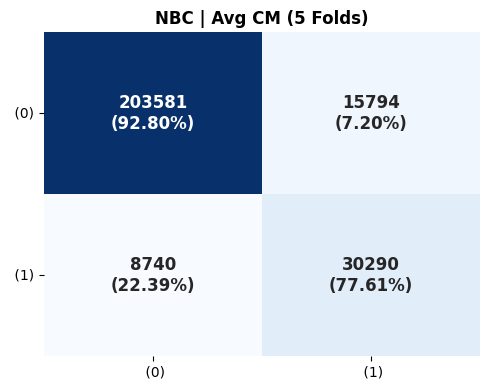

 -> Tổng thời gian 5 folds: 3.92s

--- Đang chạy mô hình: KNN ---
  + Fold 1: Xong (18.31s) - Acc: 95.30
  + Fold 2: Xong (18.86s) - Acc: 95.28
  + Fold 3: Xong (18.90s) - Acc: 95.16
  + Fold 4: Xong (18.67s) - Acc: 95.23
  + Fold 5: Xong (18.55s) - Acc: 95.20


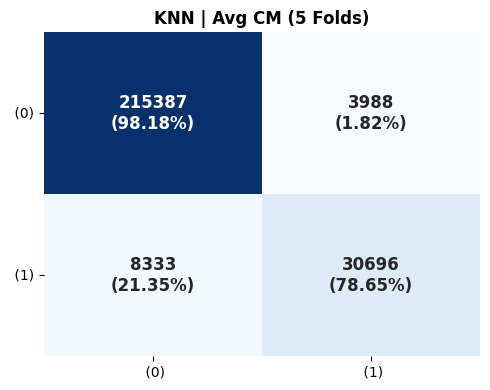

 -> Tổng thời gian 5 folds: 93.29s

--- Đang chạy mô hình: DT ---
  + Fold 1: Xong (8.66s) - Acc: 94.27
  + Fold 2: Xong (8.89s) - Acc: 94.38
  + Fold 3: Xong (8.87s) - Acc: 94.14
  + Fold 4: Xong (8.69s) - Acc: 94.25
  + Fold 5: Xong (8.92s) - Acc: 94.19


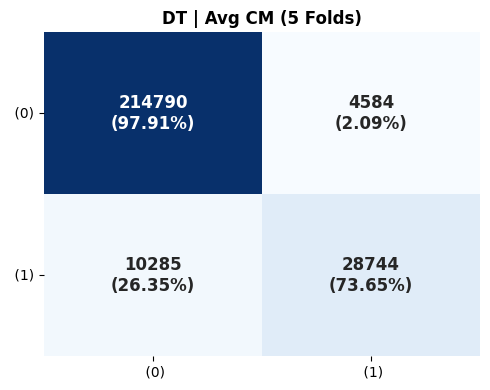

 -> Tổng thời gian 5 folds: 44.03s

--- Đang chạy mô hình: LR ---
  + Fold 1: Xong (5.86s) - Acc: 92.77
  + Fold 2: Xong (4.00s) - Acc: 92.55
  + Fold 3: Xong (3.90s) - Acc: 92.47
  + Fold 4: Xong (4.10s) - Acc: 92.52
  + Fold 5: Xong (3.78s) - Acc: 92.54


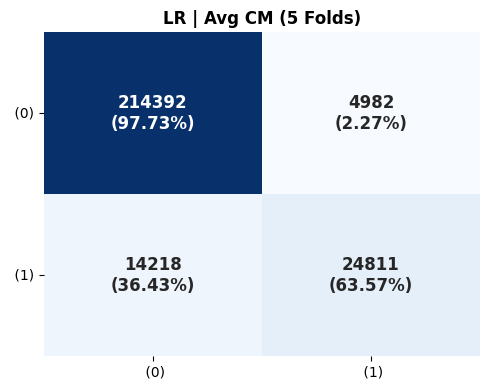

 -> Tổng thời gian 5 folds: 21.64s

--- Đang chạy mô hình: RF ---
  + Fold 1: Xong (100.28s) - Acc: 95.28
  + Fold 2: Xong (103.04s) - Acc: 95.31
  + Fold 3: Xong (104.68s) - Acc: 95.18
  + Fold 4: Xong (104.46s) - Acc: 95.23
  + Fold 5: Xong (104.99s) - Acc: 95.15


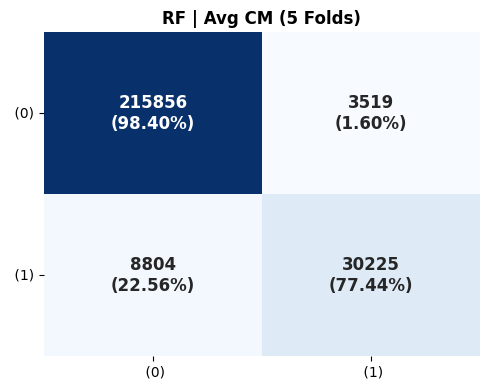

 -> Tổng thời gian 5 folds: 517.45s

--- Đang chạy mô hình: XGB ---
  + Fold 1: Xong (5.05s) - Acc: 94.76
  + Fold 2: Xong (4.89s) - Acc: 94.73
  + Fold 3: Xong (5.06s) - Acc: 94.62
  + Fold 4: Xong (4.94s) - Acc: 94.64
  + Fold 5: Xong (4.99s) - Acc: 94.63


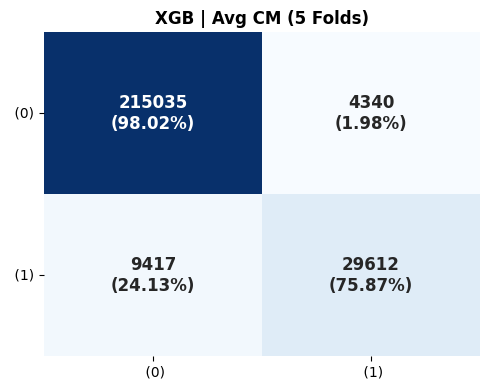

 -> Tổng thời gian 5 folds: 24.93s

--- Đang chạy mô hình: LGBM ---
[LightGBM] [Info] Number of positive: 156120, number of negative: 877502
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045341 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1033622, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.151042 -> initscore=-1.726454
[LightGBM] [Info] Start training from score -1.726454
  + Fold 1: Xong (6.07s) - Acc: 94.24
[LightGBM] [Info] Number of positive: 156120, number of negative: 877502
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047872 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1033622, number of used features: 8
[LightGBM] [Info] [binary:BoostFro

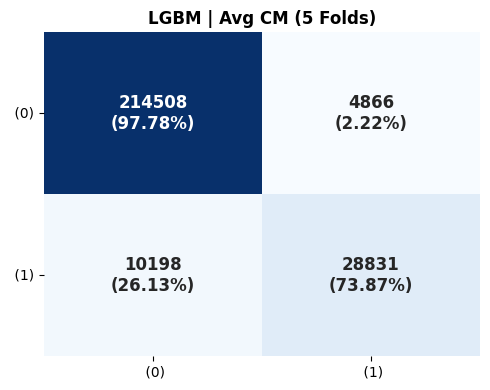

 -> Tổng thời gian 5 folds: 30.24s

[5] BẢNG TỔNG HỢP CHI TIẾT (Giá trị trung bình 5-Fold)
Model    F1  AUPR Accuracy Precision Recall Specificity Loss
   RF 83.07 92.04    95.23     89.57  77.44       98.40 0.13
  XGB 81.15 90.14    94.68     87.22  75.87       98.02 0.14
  KNN 83.28 89.98    95.23     88.50  78.65       98.18 0.31
 LGBM 79.29 88.40    94.17     85.56  73.87       97.78 0.15
   DT 79.45 87.50    94.25     86.25  73.65       97.91 0.16
   LR 72.10 82.60    92.57     83.27  63.57       97.73 0.20
  NBC 71.17 76.43    90.51     65.73  77.61       92.80 1.16


In [18]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                             confusion_matrix, log_loss, accuracy_score,
                             average_precision_score)

# Nhập các thư viện CPU cho 7 mô hình
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb 

warnings.filterwarnings("ignore")

class BenchmarkCPU_5FoldCV:
    def __init__(self, random_state=42, n_splits=5):
        self.plot_data = [] 
        self.table_data = []
        self.seed = random_state
        self.n_splits = n_splits

    def load_data(self, data_path):
        print(f"\n[1] Đang tải file nguyên vẹn để chuẩn bị 5-Fold CV...")
        
        df = pd.read_csv(data_path).fillna(0)
        
        cols_drop = ['u', 'v', 'label'] 
        feats = [c for c in df.columns if c not in cols_drop]
        
        # Dùng float64 để CPU xử lý ổn định nhất
        self.X_raw = df[feats].to_numpy()
        self.y = df['label'].to_numpy(dtype=np.int32)

        del df
        gc.collect()
        
        print(f" -> Kích thước toàn bộ dữ liệu: {self.X_raw.shape}")

    def get_models(self):
        models = []
        models.append(('NBC', GaussianNB()))
        models.append(('KNN', KNeighborsClassifier(n_neighbors=10, n_jobs=-1)))
        models.append(('DT', DecisionTreeClassifier(random_state=self.seed, max_depth=10)))
        models.append(('LR', LogisticRegression(max_iter=1000, n_jobs=-1, random_state=self.seed)))
        models.append(('RF', RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=self.seed)))
        
        xgb_model = xgb.XGBClassifier(
            n_estimators=100, eval_metric='logloss',
            tree_method='hist', n_jobs=-1, random_state=self.seed
        )
        models.append(('XGB', xgb_model))
        
        lgbm_model = lgb.LGBMClassifier(
            n_estimators=100, max_depth=15, n_jobs=-1, random_state=self.seed
        )
        models.append(('LGBM', lgbm_model))
        
        return dict(models)

    def plot_average_confusion_matrix(self, name, cms):
        plt.figure(figsize=(5, 4))
        
        avg_cm = np.mean(cms, axis=0)
        
        cm_sum = np.sum(avg_cm, axis=1, keepdims=True)
        cm_perc = avg_cm / cm_sum.astype(float) * 100
        
        labels = (np.asarray(["{0}\n({1:.2f}%)".format(int(count), perc)
                              for count, perc in zip(avg_cm.flatten(), cm_perc.flatten())])
                 ).reshape(2, 2)

        sns.heatmap(avg_cm, annot=labels, fmt='', cmap='Blues', cbar=False, 
                    annot_kws={"size": 12, "weight": "bold"})
        
        plt.title(f'{name} | Avg CM (5 Folds)', fontsize=12, fontweight='bold')
        
        plt.xticks([0.5, 1.5], [' (0)', ' (1)'])
        plt.yticks([0.5, 1.5], [' (0)', ' (1)'], rotation=0)

        plt.tight_layout()
        plt.show()

    def run_benchmark(self):
        print(f"\n[2] BẮT ĐẦU HUẤN LUYỆN TRÊN CPU (5-Fold Cross Validation)...")
        
        models_dict = self.get_models()
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.seed)

        for name, _ in models_dict.items():
            print(f"\n--- Đang chạy mô hình: {name} ---")
            fold_metrics = {'F1': [], 'Precision': [], 'Recall': [], 'Accuracy': [], 
                            'Specificity': [], 'AUPR': [], 'Loss': [], 'Time': []}
            cms = []

            for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_raw, self.y), 1):
                start_time = time.time()
                
                X_train_fold, X_val_fold = self.X_raw[train_idx], self.X_raw[val_idx]
                y_train_fold, y_val_fold = self.y[train_idx], self.y[val_idx]
                
                # Fit transform bêm trong Fold để chống rò rỉ dữ liệu
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_fold)
                X_val_scaled = scaler.transform(X_val_fold)
                
                model = self.get_models()[name]

                try:
                    model.fit(X_train_scaled, y_train_fold)
                except Exception as e:
                    print(f" -> Lỗi khi train {name} ở fold {fold}: {e}")
                    continue

                y_pred_val = model.predict(X_val_scaled)

                y_prob_val = None
                try:
                    if hasattr(model, "predict_proba"):
                        y_prob_val = model.predict_proba(X_val_scaled)
                except: pass

                cm = confusion_matrix(y_val_fold, y_pred_val)
                cms.append(cm)
                tn, fp, fn, tp = cm.ravel()
                
                # Nhân 100 để đưa về dạng phần trăm ngay từ đầu
                fold_metrics['F1'].append(f1_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Precision'].append(precision_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Recall'].append(recall_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Accuracy'].append(accuracy_score(y_val_fold, y_pred_val) * 100)
                
                spec = (tn / (tn + fp)) if (tn + fp) > 0 else 0
                fold_metrics['Specificity'].append(spec * 100)

                val_loss = np.nan
                aupr_val = np.nan
                if y_prob_val is not None:
                    try: 
                        val_loss = log_loss(y_val_fold, y_prob_val)
                        if y_prob_val.shape[1] == 2:
                            aupr_val = average_precision_score(y_val_fold, y_prob_val[:, 1]) * 100
                        else:
                            aupr_val = average_precision_score(y_val_fold, y_prob_val) * 100
                    except: pass
                
                fold_metrics['Loss'].append(val_loss if not np.isnan(val_loss) else 99.0)
                fold_metrics['AUPR'].append(aupr_val if not np.isnan(aupr_val) else 0.0)
                
                run_time = time.time() - start_time
                fold_metrics['Time'].append(run_time)
                
                print(f"  + Fold {fold}: Xong ({run_time:.2f}s) - Acc: {fold_metrics['Accuracy'][-1]:.2f}")
                gc.collect()

            self.plot_average_confusion_matrix(name, cms)

            # Lấy giá trị trung bình (Mean)
            mean_vals = {k: np.mean(v) for k, v in fold_metrics.items()}

            self.plot_data.append({
                'Model': name,
                'Loss': mean_vals['Loss'],
                'Accuracy': mean_vals['Accuracy']
            })

            # Format in ra đúng 2 số thập phân và BỎ phần cộng trừ độ lệch chuẩn
            fmt = lambda k: f"{mean_vals[k]:.2f}"
            
            self.table_data.append({
                'Model': name,
                'F1': fmt('F1'),
                'AUPR': fmt('AUPR'),
                'Accuracy': fmt('Accuracy'),
                'Precision': fmt('Precision'),
                'Recall': fmt('Recall'),
                'Specificity': fmt('Specificity'),
                'Loss': fmt('Loss'), 
                'Mean_AUPR_Sort': mean_vals['AUPR'] 
            })
            
            print(f" -> Tổng thời gian 5 folds: {np.sum(fold_metrics['Time']):.2f}s")

        print("\n[5] BẢNG TỔNG HỢP CHI TIẾT (Giá trị trung bình 5-Fold)")
        if self.table_data:
            res_df = pd.DataFrame(self.table_data).sort_values(by='Mean_AUPR_Sort', ascending=False)
            res_df_display = res_df.drop(columns=['Mean_AUPR_Sort']) 
            print(res_df_display.to_string(index=False))

    def plot_final_loss_chart(self):
        if not self.plot_data: return
        df_plot = pd.DataFrame(self.plot_data)
        df_plot = df_plot[df_plot['Loss'] < 90].sort_values(by='Loss', ascending=True)

        plt.figure(figsize=(10, 5))
        plt.plot(df_plot['Model'], df_plot['Loss'], marker='o', linestyle='-', color='#d62728', markersize=8, linewidth=2)
        
        plt.ylabel('Mean Log Loss')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)
        
        for i in range(len(df_plot)):
            val = df_plot['Loss'].iloc[i]
            plt.annotate(f"{val:.2f}", (df_plot['Model'].iloc[i], val), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_final_accuracy_chart(self):
        if not self.plot_data: return
        df = pd.DataFrame(self.plot_data).sort_values(by='Accuracy', ascending=False)

        plt.figure(figsize=(10, 6))
        plt.plot(df['Model'], df['Accuracy'], marker='o', linestyle='-', color='#1f77b4', markersize=8, linewidth=2)
        
        plt.xlabel('Mô hình', fontsize=12)
        plt.ylabel('Mean Accuracy (%)', fontsize=12)
        plt.ylim(0, 110) 
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)

        for i in range(len(df)):
            val = df['Accuracy'].iloc[i]
            plt.annotate(f'{val:.2f}', (df['Model'].iloc[i], val), 
                         textcoords="offset points", xytext=(0, 10), 
                         ha='center', fontweight='bold', fontsize=10)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    DATA_FILE = "/kaggle/input/datasets/vungocthien/12ft-riengle/Topological_Features.csv"
    
    if os.path.exists(DATA_FILE):
        bencher = BenchmarkCPU_5FoldCV(random_state=42, n_splits=5)
        bencher.load_data(DATA_FILE)
        bencher.run_benchmark()
    else:
        print(f"Lỗi: Không tìm thấy file {DATA_FILE}. Hãy kiểm tra lại đường dẫn.")

---

# Thực nghiệm với đặc trưng sinh học

In [ ]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/vungocthien/dataset-dont-split/Final_Dataset_DDI.csv')
df.head()

In [ ]:
df = df.drop(["cn", "jc","pa", "rai", "aai", "ccn", "cra", "wic"], axis = 1)

In [ ]:
df

In [ ]:
from sklearn.utils import shuffle
df_shuffled = shuffle(df, random_state=42)

In [ ]:
df_shuffled = df_shuffled.reset_index(drop=True)
df_shuffled.to_csv('Semantic_Features.csv', index = False)

In [ ]:
df_shuffled

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                             confusion_matrix, log_loss, accuracy_score,
                             average_precision_score)

# Nhập các thư viện CPU cho 7 mô hình
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb 

warnings.filterwarnings("ignore")

class BenchmarkCPU_5FoldCV:
    def __init__(self, random_state=42, n_splits=5):
        self.plot_data = [] 
        self.table_data = []
        self.seed = random_state
        self.n_splits = n_splits

    def load_data(self, data_path):
        print(f"\n[1] Đang tải file nguyên vẹn để chuẩn bị 5-Fold CV...")
        
        df = pd.read_csv(data_path).fillna(0)
        
        cols_drop = ['u', 'v', 'label'] 
        feats = [c for c in df.columns if c not in cols_drop]
        
        # Dùng float64 để CPU xử lý ổn định nhất
        self.X_raw = df[feats].to_numpy()
        self.y = df['label'].to_numpy(dtype=np.int32)

        del df
        gc.collect()
        
        print(f" -> Kích thước toàn bộ dữ liệu: {self.X_raw.shape}")

    def get_models(self):
        models = []
        models.append(('NBC', GaussianNB()))
        models.append(('KNN', KNeighborsClassifier(n_neighbors=10, n_jobs=-1)))
        models.append(('DT', DecisionTreeClassifier(random_state=self.seed, max_depth=10)))
        models.append(('LR', LogisticRegression(max_iter=1000, n_jobs=-1, random_state=self.seed)))
        models.append(('RF', RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=self.seed)))
        
        xgb_model = xgb.XGBClassifier(
            n_estimators=100, eval_metric='logloss',
            tree_method='hist', n_jobs=-1, random_state=self.seed
        )
        models.append(('XGB', xgb_model))
        
        lgbm_model = lgb.LGBMClassifier(
            n_estimators=100, max_depth=15, n_jobs=-1, random_state=self.seed
        )
        models.append(('LGBM', lgbm_model))
        
        return dict(models)

    def plot_average_confusion_matrix(self, name, cms):
        plt.figure(figsize=(5, 4))
        
        avg_cm = np.mean(cms, axis=0)
        
        cm_sum = np.sum(avg_cm, axis=1, keepdims=True)
        cm_perc = avg_cm / cm_sum.astype(float) * 100
        
        labels = (np.asarray(["{0}\n({1:.2f}%)".format(int(count), perc)
                              for count, perc in zip(avg_cm.flatten(), cm_perc.flatten())])
                 ).reshape(2, 2)

        sns.heatmap(avg_cm, annot=labels, fmt='', cmap='Blues', cbar=False, 
                    annot_kws={"size": 12, "weight": "bold"})
        
        plt.title(f'{name} | Avg CM (5 Folds)', fontsize=12, fontweight='bold')
        
        plt.xticks([0.5, 1.5], [' (0)', ' (1)'])
        plt.yticks([0.5, 1.5], [' (0)', ' (1)'], rotation=0)

        plt.tight_layout()
        plt.show()

    def run_benchmark(self):
        print(f"\n[2] BẮT ĐẦU HUẤN LUYỆN TRÊN CPU (5-Fold Cross Validation)...")
        
        models_dict = self.get_models()
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.seed)

        for name, _ in models_dict.items():
            print(f"\n--- Đang chạy mô hình: {name} ---")
            fold_metrics = {'F1': [], 'Precision': [], 'Recall': [], 'Accuracy': [], 
                            'Specificity': [], 'AUPR': [], 'Loss': [], 'Time': []}
            cms = []

            for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_raw, self.y), 1):
                start_time = time.time()
                
                X_train_fold, X_val_fold = self.X_raw[train_idx], self.X_raw[val_idx]
                y_train_fold, y_val_fold = self.y[train_idx], self.y[val_idx]
                
                # Fit transform bêm trong Fold để chống rò rỉ dữ liệu
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_fold)
                X_val_scaled = scaler.transform(X_val_fold)
                
                model = self.get_models()[name]

                try:
                    model.fit(X_train_scaled, y_train_fold)
                except Exception as e:
                    print(f" -> Lỗi khi train {name} ở fold {fold}: {e}")
                    continue

                y_pred_val = model.predict(X_val_scaled)

                y_prob_val = None
                try:
                    if hasattr(model, "predict_proba"):
                        y_prob_val = model.predict_proba(X_val_scaled)
                except: pass

                cm = confusion_matrix(y_val_fold, y_pred_val)
                cms.append(cm)
                tn, fp, fn, tp = cm.ravel()
                
                # Nhân 100 để đưa về dạng phần trăm ngay từ đầu
                fold_metrics['F1'].append(f1_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Precision'].append(precision_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Recall'].append(recall_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Accuracy'].append(accuracy_score(y_val_fold, y_pred_val) * 100)
                
                spec = (tn / (tn + fp)) if (tn + fp) > 0 else 0
                fold_metrics['Specificity'].append(spec * 100)

                val_loss = np.nan
                aupr_val = np.nan
                if y_prob_val is not None:
                    try: 
                        val_loss = log_loss(y_val_fold, y_prob_val)
                        if y_prob_val.shape[1] == 2:
                            aupr_val = average_precision_score(y_val_fold, y_prob_val[:, 1]) * 100
                        else:
                            aupr_val = average_precision_score(y_val_fold, y_prob_val) * 100
                    except: pass
                
                fold_metrics['Loss'].append(val_loss if not np.isnan(val_loss) else 99.0)
                fold_metrics['AUPR'].append(aupr_val if not np.isnan(aupr_val) else 0.0)
                
                run_time = time.time() - start_time
                fold_metrics['Time'].append(run_time)
                
                print(f"  + Fold {fold}: Xong ({run_time:.2f}s) - Acc: {fold_metrics['Accuracy'][-1]:.2f}")
                gc.collect()

            self.plot_average_confusion_matrix(name, cms)

            # Lấy giá trị trung bình (Mean)
            mean_vals = {k: np.mean(v) for k, v in fold_metrics.items()}

            self.plot_data.append({
                'Model': name,
                'Loss': mean_vals['Loss'],
                'Accuracy': mean_vals['Accuracy']
            })

            # Format in ra đúng 2 số thập phân và BỎ phần cộng trừ độ lệch chuẩn
            fmt = lambda k: f"{mean_vals[k]:.2f}"
            
            self.table_data.append({
                'Model': name,
                'F1': fmt('F1'),
                'AUPR': fmt('AUPR'),
                'Accuracy': fmt('Accuracy'),
                'Precision': fmt('Precision'),
                'Recall': fmt('Recall'),
                'Specificity': fmt('Specificity'),
                'Loss': fmt('Loss'), 
                'Mean_AUPR_Sort': mean_vals['AUPR'] 
            })
            
            print(f" -> Tổng thời gian 5 folds: {np.sum(fold_metrics['Time']):.2f}s")

        print("\n[5] BẢNG TỔNG HỢP CHI TIẾT (Giá trị trung bình 5-Fold)")
        if self.table_data:
            res_df = pd.DataFrame(self.table_data).sort_values(by='Mean_AUPR_Sort', ascending=False)
            res_df_display = res_df.drop(columns=['Mean_AUPR_Sort']) 
            print(res_df_display.to_string(index=False))

    def plot_final_loss_chart(self):
        if not self.plot_data: return
        df_plot = pd.DataFrame(self.plot_data)
        df_plot = df_plot[df_plot['Loss'] < 90].sort_values(by='Loss', ascending=True)

        plt.figure(figsize=(10, 5))
        plt.plot(df_plot['Model'], df_plot['Loss'], marker='o', linestyle='-', color='#d62728', markersize=8, linewidth=2)
        
        plt.ylabel('Mean Log Loss')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)
        
        for i in range(len(df_plot)):
            val = df_plot['Loss'].iloc[i]
            plt.annotate(f"{val:.2f}", (df_plot['Model'].iloc[i], val), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_final_accuracy_chart(self):
        if not self.plot_data: return
        df = pd.DataFrame(self.plot_data).sort_values(by='Accuracy', ascending=False)

        plt.figure(figsize=(10, 6))
        plt.plot(df['Model'], df['Accuracy'], marker='o', linestyle='-', color='#1f77b4', markersize=8, linewidth=2)
        
        plt.xlabel('Mô hình', fontsize=12)
        plt.ylabel('Mean Accuracy (%)', fontsize=12)
        plt.ylim(0, 110) 
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)

        for i in range(len(df)):
            val = df['Accuracy'].iloc[i]
            plt.annotate(f'{val:.2f}', (df['Model'].iloc[i], val), 
                         textcoords="offset points", xytext=(0, 10), 
                         ha='center', fontweight='bold', fontsize=10)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    DATA_FILE = "/kaggle/working/Semantic_Features.csv"
    
    if os.path.exists(DATA_FILE):
        bencher = BenchmarkCPU_5FoldCV(random_state=42, n_splits=5)
        bencher.load_data(DATA_FILE)
        bencher.run_benchmark()
    else:
        print(f"Lỗi: Không tìm thấy file {DATA_FILE}. Hãy kiểm tra lại đường dẫn.")

---

# **Đánh giá mức độ quan trọng của các đặc trưng**

[1] Đang tải và tiền xử lý dữ liệu...
 -> Kích thước tập Train: (852738, 12)
 -> Kích thước tập Test:  (439290, 12)

[2] Đang huấn luyện mô hình XGBoost...
 -> Độ chính xác (Accuracy) trên tập Test: 0.9469

[3] Đang chạy phân tích SHAP Values và xuất ảnh...
 -> Đã lưu biểu đồ Bar tại: shap_high_res_images/shap_bar_plot.png


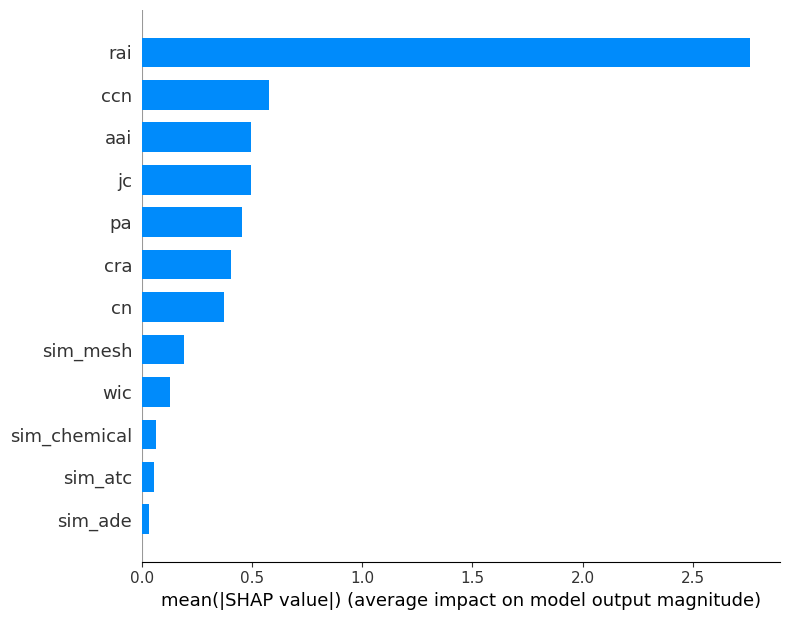

 -> Đã lưu biểu đồ Dot tại: shap_high_res_images/shap_summary_dot.png


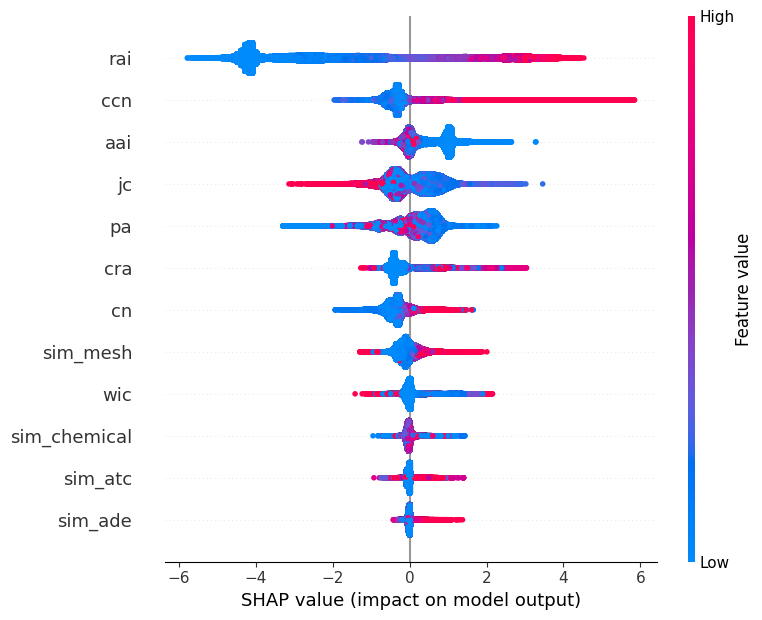


[Hoàn tất] Toàn bộ quá trình trích xuất và xuất ảnh đã thực hiện xong!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
import os
import warnings

from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")

class FeatureImportanceAnalyzer:
    """
    Class hỗ trợ phân tích và trích xuất độ quan trọng của đặc trưng 
    sử dụng SHAP values với chất lượng ảnh xuất ra cực cao.
    """
    def __init__(self, train_path, test_path):
        self.train_path = train_path
        self.test_path = test_path
        self.model = None
        
        # Biến lưu trữ dữ liệu
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None
        self.feats = []

    def load_and_preprocess_data(self):
        """Tải dữ liệu, xử lý missing values và tách features/labels."""
        print("[1] Đang tải và tiền xử lý dữ liệu...")
        df_train = pd.read_csv(self.train_path).fillna(0)
        df_test = pd.read_csv(self.test_path).fillna(0)
        
        # Loại bỏ các cột không phải là đặc trưng
        cols_drop = ['u', 'v', 'label'] 
        self.feats = [c for c in df_train.columns if c not in cols_drop]
        
        self.X_train = df_train[self.feats]
        self.y_train = df_train['label']
        
        self.X_test = df_test[self.feats]
        self.y_test = df_test['label']

        print(f" -> Kích thước tập Train: {self.X_train.shape}")
        print(f" -> Kích thước tập Test:  {self.X_test.shape}")

    def train_model(self):
        """Huấn luyện mô hình XGBoost làm nền tảng cho việc giải thích."""
        print("\n[2] Đang huấn luyện mô hình XGBoost...")
        self.model = xgb.XGBClassifier(
            n_estimators=100, 
            tree_method='hist', 
            random_state=42,
            n_jobs=-1
        )
        self.model.fit(self.X_train, self.y_train)
        
        # Đánh giá nhanh hiệu suất cơ sở
        preds = self.model.predict(self.X_test)
        acc = accuracy_score(self.y_test, preds)
        print(f" -> Độ chính xác (Accuracy) trên tập Test: {acc:.4f}")

    def analyze_shap_importance(self):
        """Tính toán, trực quan hóa và lưu ảnh SHAP values chất lượng cao."""
        print("\n[3] Đang chạy phân tích SHAP Values và xuất ảnh...")
        
        explainer = shap.TreeExplainer(self.model)
        shap_values = explainer.shap_values(self.X_test)
        
        # Tạo thư mục chứa ảnh nếu chưa tồn tại
        out_dir = "shap_high_res_images"
        os.makedirs(out_dir, exist_ok=True)
        
        # ---------------------------------------------------------
        # 1. Biểu đồ SHAP Bar Plot (Độ lớn trung bình)
        # ---------------------------------------------------------
        plt.figure(figsize=(10, 6))
        
        # Bắt buộc show=False để plt chưa bị xóa bộ nhớ trước khi savefig
        shap.summary_plot(shap_values, self.X_test, plot_type="bar", feature_names=self.feats, show=False)
        
        # Lưu ảnh với chất lượng DPI cao và cắt viền (bbox_inches='tight')
        bar_path = os.path.join(out_dir, "shap_bar_plot.png")
        plt.savefig(bar_path, bbox_inches='tight', dpi=600, transparent=False, facecolor='white')
        print(f" -> Đã lưu biểu đồ Bar tại: {bar_path}")
        plt.show()

        # ---------------------------------------------------------
        # 2. Biểu đồ SHAP Summary Plot (Phân bổ chi tiết dạng chấm)
        # ---------------------------------------------------------
        plt.figure(figsize=(10, 6))
        
        shap.summary_plot(shap_values, self.X_test, plot_type="dot", feature_names=self.feats, show=False)
        
        dot_path = os.path.join(out_dir, "shap_summary_dot.png")
        plt.savefig(dot_path, bbox_inches='tight', dpi=600, transparent=False, facecolor='white')
        print(f" -> Đã lưu biểu đồ Dot tại: {dot_path}")
        plt.show()

    def run_all_analyses(self):
        """Hàm điều phối chạy toàn bộ quy trình."""
        self.load_and_preprocess_data()
        self.train_model()
        self.analyze_shap_importance()
        print("\n[Hoàn tất] Toàn bộ quá trình trích xuất và xuất ảnh đã thực hiện xong!")


if __name__ == "__main__":
    TRAIN_FILE = "/kaggle/input/datasets/vungocthien/dataset-trainmodel/train_data.csv"
    TEST_FILE = "/kaggle/input/datasets/vungocthien/dataset-trainmodel/test_data.csv"
    
    if os.path.exists(TRAIN_FILE) and os.path.exists(TEST_FILE):
        # Khởi tạo đối tượng
        analyzer = FeatureImportanceAnalyzer(TRAIN_FILE, TEST_FILE)
        # Chạy toàn bộ pipeline
        analyzer.run_all_analyses()
    else:
        print("Lỗi: Không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn!")

---

# Bỏ 3 đặc trưng ít ý nghĩa ATC, SMILES, ADE

In [ ]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/vungocthien/dataset-dont-split/Final_Dataset_DDI.csv")

df = df.drop(["sim_atc","sim_ade", "sim_chemical"], axis=1)
from sklearn.utils import shuffle
df_shuffled = shuffle(df, random_state=42)

df_shuffled = df_shuffled.reset_index(drop=True)
df_shuffled.to_csv('9DacTrung.csv', index = False)

In [ ]:
df_shuffled

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                             confusion_matrix, log_loss, accuracy_score,
                             average_precision_score)

# Nhập các thư viện CPU cho 7 mô hình
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb 

warnings.filterwarnings("ignore")

class BenchmarkCPU_5FoldCV:
    def __init__(self, random_state=42, n_splits=5):
        self.plot_data = [] 
        self.table_data = []
        self.seed = random_state
        self.n_splits = n_splits

    def load_data(self, data_path):
        print(f"\n[1] Đang tải file nguyên vẹn để chuẩn bị 5-Fold CV...")
        
        df = pd.read_csv(data_path).fillna(0)
        
        cols_drop = ['u', 'v', 'label'] 
        feats = [c for c in df.columns if c not in cols_drop]
        
        # Dùng float64 để CPU xử lý ổn định nhất
        self.X_raw = df[feats].to_numpy()
        self.y = df['label'].to_numpy(dtype=np.int32)

        del df
        gc.collect()
        
        print(f" -> Kích thước toàn bộ dữ liệu: {self.X_raw.shape}")

    def get_models(self):
        models = []
        models.append(('NBC', GaussianNB()))
        models.append(('KNN', KNeighborsClassifier(n_neighbors=10, n_jobs=-1)))
        models.append(('DT', DecisionTreeClassifier(random_state=self.seed, max_depth=10)))
        models.append(('LR', LogisticRegression(max_iter=1000, n_jobs=-1, random_state=self.seed)))
        models.append(('RF', RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=self.seed)))
        
        xgb_model = xgb.XGBClassifier(
            n_estimators=100, eval_metric='logloss',
            tree_method='hist', n_jobs=-1, random_state=self.seed
        )
        models.append(('XGB', xgb_model))
        
        lgbm_model = lgb.LGBMClassifier(
            n_estimators=100, max_depth=15, n_jobs=-1, random_state=self.seed
        )
        models.append(('LGBM', lgbm_model))
        
        return dict(models)

    def plot_average_confusion_matrix(self, name, cms):
        plt.figure(figsize=(5, 4))
        
        avg_cm = np.mean(cms, axis=0)
        
        cm_sum = np.sum(avg_cm, axis=1, keepdims=True)
        cm_perc = avg_cm / cm_sum.astype(float) * 100
        
        labels = (np.asarray(["{0}\n({1:.2f}%)".format(int(count), perc)
                              for count, perc in zip(avg_cm.flatten(), cm_perc.flatten())])
                 ).reshape(2, 2)

        sns.heatmap(avg_cm, annot=labels, fmt='', cmap='Blues', cbar=False, 
                    annot_kws={"size": 12, "weight": "bold"})
        
        plt.title(f'{name} | Avg CM (5 Folds)', fontsize=12, fontweight='bold')
        
        plt.xticks([0.5, 1.5], [' (0)', ' (1)'])
        plt.yticks([0.5, 1.5], [' (0)', ' (1)'], rotation=0)

        plt.tight_layout()
        plt.show()

    def run_benchmark(self):
        print(f"\n[2] BẮT ĐẦU HUẤN LUYỆN TRÊN CPU (5-Fold Cross Validation)...")
        
        models_dict = self.get_models()
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.seed)

        for name, _ in models_dict.items():
            print(f"\n--- Đang chạy mô hình: {name} ---")
            fold_metrics = {'F1': [], 'Precision': [], 'Recall': [], 'Accuracy': [], 
                            'Specificity': [], 'AUPR': [], 'Loss': [], 'Time': []}
            cms = []

            for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_raw, self.y), 1):
                start_time = time.time()
                
                X_train_fold, X_val_fold = self.X_raw[train_idx], self.X_raw[val_idx]
                y_train_fold, y_val_fold = self.y[train_idx], self.y[val_idx]
                
                # Fit transform bêm trong Fold để chống rò rỉ dữ liệu
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_fold)
                X_val_scaled = scaler.transform(X_val_fold)
                
                model = self.get_models()[name]

                try:
                    model.fit(X_train_scaled, y_train_fold)
                except Exception as e:
                    print(f" -> Lỗi khi train {name} ở fold {fold}: {e}")
                    continue

                y_pred_val = model.predict(X_val_scaled)

                y_prob_val = None
                try:
                    if hasattr(model, "predict_proba"):
                        y_prob_val = model.predict_proba(X_val_scaled)
                except: pass

                cm = confusion_matrix(y_val_fold, y_pred_val)
                cms.append(cm)
                tn, fp, fn, tp = cm.ravel()
                
                # Nhân 100 để đưa về dạng phần trăm ngay từ đầu
                fold_metrics['F1'].append(f1_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Precision'].append(precision_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Recall'].append(recall_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Accuracy'].append(accuracy_score(y_val_fold, y_pred_val) * 100)
                
                spec = (tn / (tn + fp)) if (tn + fp) > 0 else 0
                fold_metrics['Specificity'].append(spec * 100)

                val_loss = np.nan
                aupr_val = np.nan
                if y_prob_val is not None:
                    try: 
                        val_loss = log_loss(y_val_fold, y_prob_val)
                        if y_prob_val.shape[1] == 2:
                            aupr_val = average_precision_score(y_val_fold, y_prob_val[:, 1]) * 100
                        else:
                            aupr_val = average_precision_score(y_val_fold, y_prob_val) * 100
                    except: pass
                
                fold_metrics['Loss'].append(val_loss if not np.isnan(val_loss) else 99.0)
                fold_metrics['AUPR'].append(aupr_val if not np.isnan(aupr_val) else 0.0)
                
                run_time = time.time() - start_time
                fold_metrics['Time'].append(run_time)
                
                print(f"  + Fold {fold}: Xong ({run_time:.2f}s) - Acc: {fold_metrics['Accuracy'][-1]:.2f}")
                gc.collect()

            self.plot_average_confusion_matrix(name, cms)

            # Lấy giá trị trung bình (Mean)
            mean_vals = {k: np.mean(v) for k, v in fold_metrics.items()}

            self.plot_data.append({
                'Model': name,
                'Loss': mean_vals['Loss'],
                'Accuracy': mean_vals['Accuracy']
            })

            # Format in ra đúng 2 số thập phân và BỎ phần cộng trừ độ lệch chuẩn
            fmt = lambda k: f"{mean_vals[k]:.2f}"
            
            self.table_data.append({
                'Model': name,
                'F1': fmt('F1'),
                'AUPR': fmt('AUPR'),
                'Accuracy': fmt('Accuracy'),
                'Precision': fmt('Precision'),
                'Recall': fmt('Recall'),
                'Specificity': fmt('Specificity'),
                'Loss': fmt('Loss'), 
                'Mean_AUPR_Sort': mean_vals['AUPR'] 
            })
            
            print(f" -> Tổng thời gian 5 folds: {np.sum(fold_metrics['Time']):.2f}s")

        print("\n[5] BẢNG TỔNG HỢP CHI TIẾT (Giá trị trung bình 5-Fold)")
        if self.table_data:
            res_df = pd.DataFrame(self.table_data).sort_values(by='Mean_AUPR_Sort', ascending=False)
            res_df_display = res_df.drop(columns=['Mean_AUPR_Sort']) 
            print(res_df_display.to_string(index=False))

    def plot_final_loss_chart(self):
        if not self.plot_data: return
        df_plot = pd.DataFrame(self.plot_data)
        df_plot = df_plot[df_plot['Loss'] < 90].sort_values(by='Loss', ascending=True)

        plt.figure(figsize=(10, 5))
        plt.plot(df_plot['Model'], df_plot['Loss'], marker='o', linestyle='-', color='#d62728', markersize=8, linewidth=2)
        
        plt.ylabel('Mean Log Loss')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)
        
        for i in range(len(df_plot)):
            val = df_plot['Loss'].iloc[i]
            plt.annotate(f"{val:.2f}", (df_plot['Model'].iloc[i], val), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_final_accuracy_chart(self):
        if not self.plot_data: return
        df = pd.DataFrame(self.plot_data).sort_values(by='Accuracy', ascending=False)

        plt.figure(figsize=(10, 6))
        plt.plot(df['Model'], df['Accuracy'], marker='o', linestyle='-', color='#1f77b4', markersize=8, linewidth=2)
        
        plt.xlabel('Mô hình', fontsize=12)
        plt.ylabel('Mean Accuracy (%)', fontsize=12)
        plt.ylim(0, 110) 
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)

        for i in range(len(df)):
            val = df['Accuracy'].iloc[i]
            plt.annotate(f'{val:.2f}', (df['Model'].iloc[i], val), 
                         textcoords="offset points", xytext=(0, 10), 
                         ha='center', fontweight='bold', fontsize=10)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    DATA_FILE = "/kaggle/working/9DacTrung.csv"
    
    if os.path.exists(DATA_FILE):
        bencher = BenchmarkCPU_5FoldCV(random_state=42, n_splits=5)
        bencher.load_data(DATA_FILE)
        bencher.run_benchmark()
    else:
        print(f"Lỗi: Không tìm thấy file {DATA_FILE}. Hãy kiểm tra lại đường dẫn.")

---

# Bỏ 2 đặc trung ADE, ATC

In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/vungocthien/dataset-dont-split/Final_Dataset_DDI.csv")

df = df.drop(["sim_atc","sim_ade"], axis=1)
from sklearn.utils import shuffle
df_shuffled = shuffle(df, random_state=42)

df_shuffled = df_shuffled.reset_index(drop=True)
df_shuffled.to_csv('10DacTrung.csv', index = False)


[1] Đang tải file nguyên vẹn để chuẩn bị 5-Fold CV...
 -> Kích thước toàn bộ dữ liệu: (1292028, 10)

[2] BẮT ĐẦU HUẤN LUYỆN TRÊN CPU (5-Fold Cross Validation)...

--- Đang chạy mô hình: NBC ---
  + Fold 1: Xong (0.93s) - Acc: 90.48
  + Fold 2: Xong (0.91s) - Acc: 90.39
  + Fold 3: Xong (0.94s) - Acc: 90.32
  + Fold 4: Xong (0.92s) - Acc: 90.40
  + Fold 5: Xong (0.91s) - Acc: 90.33


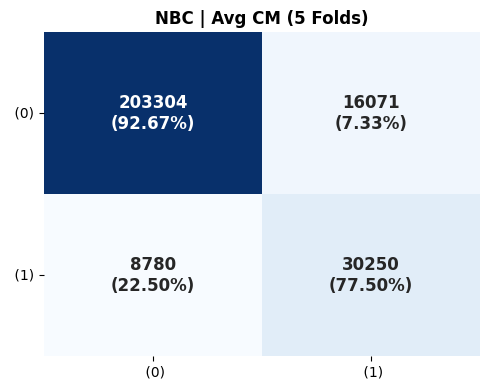

 -> Tổng thời gian 5 folds: 4.61s

--- Đang chạy mô hình: KNN ---
  + Fold 1: Xong (34.11s) - Acc: 94.31
  + Fold 2: Xong (36.57s) - Acc: 94.29
  + Fold 3: Xong (36.63s) - Acc: 94.15
  + Fold 4: Xong (37.28s) - Acc: 94.22
  + Fold 5: Xong (37.66s) - Acc: 94.24


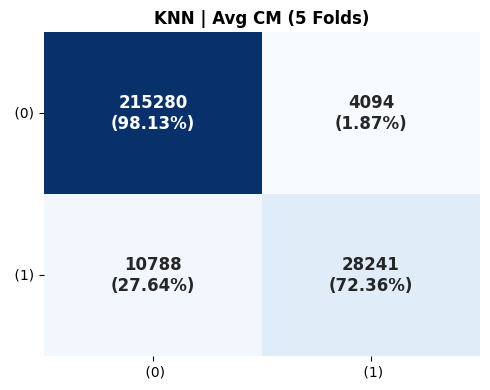

 -> Tổng thời gian 5 folds: 182.25s

--- Đang chạy mô hình: DT ---
  + Fold 1: Xong (12.46s) - Acc: 94.23
  + Fold 2: Xong (12.77s) - Acc: 94.37
  + Fold 3: Xong (12.63s) - Acc: 94.14
  + Fold 4: Xong (12.34s) - Acc: 94.21
  + Fold 5: Xong (12.64s) - Acc: 94.22


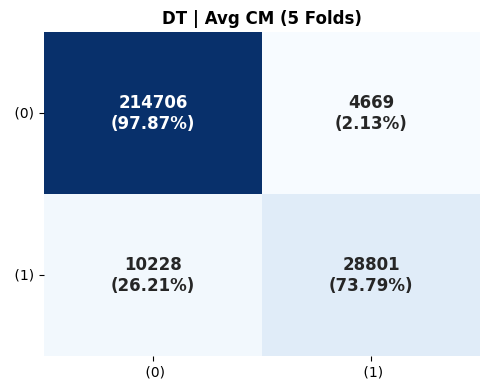

 -> Tổng thời gian 5 folds: 62.85s

--- Đang chạy mô hình: LR ---
  + Fold 1: Xong (7.35s) - Acc: 92.78
  + Fold 2: Xong (6.69s) - Acc: 92.70
  + Fold 3: Xong (6.47s) - Acc: 92.62
  + Fold 4: Xong (7.02s) - Acc: 92.65
  + Fold 5: Xong (6.43s) - Acc: 92.67


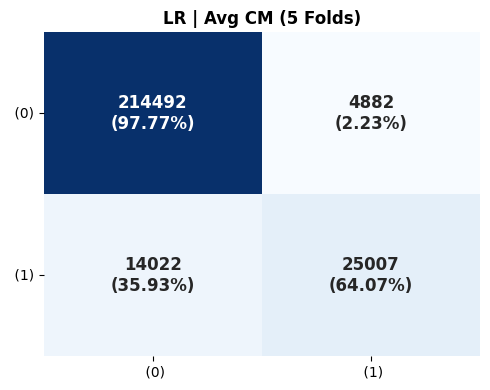

 -> Tổng thời gian 5 folds: 33.97s

--- Đang chạy mô hình: RF ---
  + Fold 1: Xong (152.02s) - Acc: 95.31
  + Fold 2: Xong (153.15s) - Acc: 95.31
  + Fold 3: Xong (159.11s) - Acc: 95.17
  + Fold 4: Xong (160.71s) - Acc: 95.23
  + Fold 5: Xong (149.80s) - Acc: 95.20


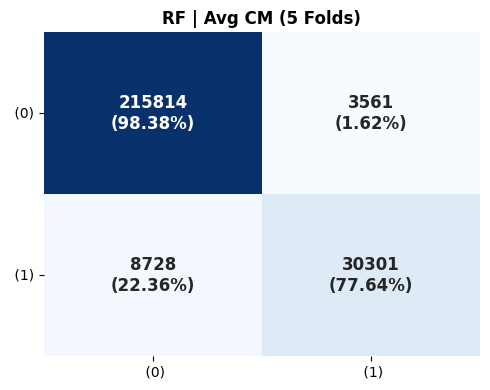

 -> Tổng thời gian 5 folds: 774.79s

--- Đang chạy mô hình: XGB ---
  + Fold 1: Xong (5.41s) - Acc: 94.78
  + Fold 2: Xong (5.45s) - Acc: 94.75
  + Fold 3: Xong (5.27s) - Acc: 94.66
  + Fold 4: Xong (5.40s) - Acc: 94.65
  + Fold 5: Xong (5.28s) - Acc: 94.64


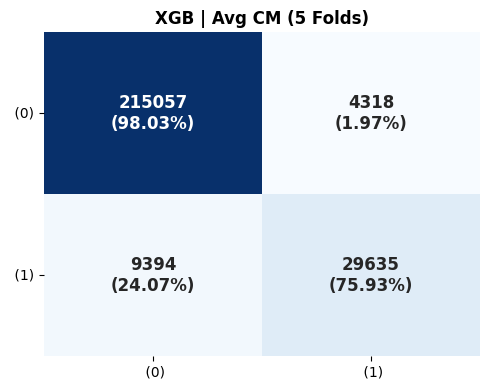

 -> Tổng thời gian 5 folds: 26.81s

--- Đang chạy mô hình: LGBM ---
[LightGBM] [Info] Number of positive: 156120, number of negative: 877502
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.058047 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 1033622, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.151042 -> initscore=-1.726454
[LightGBM] [Info] Start training from score -1.726454
  + Fold 1: Xong (6.33s) - Acc: 94.26
[LightGBM] [Info] Number of positive: 156120, number of negative: 877502
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054781 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 1033622, number of used features: 10
[LightGBM] [Info] [binary:BoostF

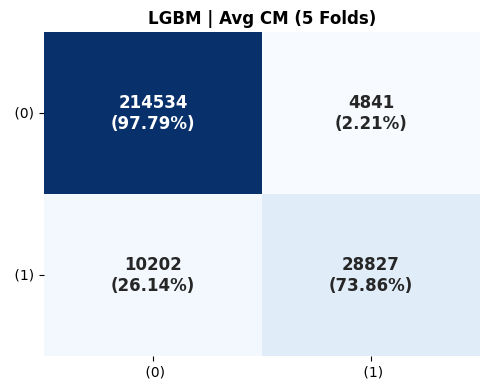

 -> Tổng thời gian 5 folds: 31.46s

[5] BẢNG TỔNG HỢP CHI TIẾT (Giá trị trung bình 5-Fold)
Model    F1  AUPR Accuracy Precision Recall Specificity Loss
   RF 83.14 91.99    95.24     89.48  77.64       98.38 0.13
  XGB 81.21 90.19    94.69     87.28  75.93       98.03 0.14
 LGBM 79.31 88.37    94.18     85.62  73.86       97.79 0.15
   DT 79.45 87.36    94.23     86.05  73.79       97.87 0.17
  KNN 79.15 85.34    94.24     87.34  72.36       98.13 0.44
   LR 72.57 82.90    92.68     83.66  64.07       97.77 0.20
  NBC 70.88 75.32    90.38     65.30  77.50       92.67 1.22


In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                             confusion_matrix, log_loss, accuracy_score,
                             average_precision_score)

# Nhập các thư viện CPU cho 7 mô hình
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb 

warnings.filterwarnings("ignore")

class BenchmarkCPU_5FoldCV:
    def __init__(self, random_state=42, n_splits=5):
        self.plot_data = [] 
        self.table_data = []
        self.seed = random_state
        self.n_splits = n_splits

    def load_data(self, data_path):
        print(f"\n[1] Đang tải file nguyên vẹn để chuẩn bị 5-Fold CV...")
        
        df = pd.read_csv(data_path).fillna(0)
        
        cols_drop = ['u', 'v', 'label'] 
        feats = [c for c in df.columns if c not in cols_drop]
        
        # Dùng float64 để CPU xử lý ổn định nhất
        self.X_raw = df[feats].to_numpy()
        self.y = df['label'].to_numpy(dtype=np.int32)

        del df
        gc.collect()
        
        print(f" -> Kích thước toàn bộ dữ liệu: {self.X_raw.shape}")

    def get_models(self):
        models = []
        models.append(('NBC', GaussianNB()))
        models.append(('KNN', KNeighborsClassifier(n_neighbors=10, n_jobs=-1)))
        models.append(('DT', DecisionTreeClassifier(random_state=self.seed, max_depth=10)))
        models.append(('LR', LogisticRegression(max_iter=1000, n_jobs=-1, random_state=self.seed)))
        models.append(('RF', RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=self.seed)))
        
        xgb_model = xgb.XGBClassifier(
            n_estimators=100, eval_metric='logloss',
            tree_method='hist', n_jobs=-1, random_state=self.seed
        )
        models.append(('XGB', xgb_model))
        
        lgbm_model = lgb.LGBMClassifier(
            n_estimators=100, max_depth=15, n_jobs=-1, random_state=self.seed
        )
        models.append(('LGBM', lgbm_model))
        
        return dict(models)

    def plot_average_confusion_matrix(self, name, cms):
        plt.figure(figsize=(5, 4))
        
        avg_cm = np.mean(cms, axis=0)
        
        cm_sum = np.sum(avg_cm, axis=1, keepdims=True)
        cm_perc = avg_cm / cm_sum.astype(float) * 100
        
        labels = (np.asarray(["{0}\n({1:.2f}%)".format(int(count), perc)
                              for count, perc in zip(avg_cm.flatten(), cm_perc.flatten())])
                 ).reshape(2, 2)

        sns.heatmap(avg_cm, annot=labels, fmt='', cmap='Blues', cbar=False, 
                    annot_kws={"size": 12, "weight": "bold"})
        
        plt.title(f'{name} | Avg CM (5 Folds)', fontsize=12, fontweight='bold')
        
        plt.xticks([0.5, 1.5], [' (0)', ' (1)'])
        plt.yticks([0.5, 1.5], [' (0)', ' (1)'], rotation=0)

        plt.tight_layout()
        plt.show()

    def run_benchmark(self):
        print(f"\n[2] BẮT ĐẦU HUẤN LUYỆN TRÊN CPU (5-Fold Cross Validation)...")
        
        models_dict = self.get_models()
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.seed)

        for name, _ in models_dict.items():
            print(f"\n--- Đang chạy mô hình: {name} ---")
            fold_metrics = {'F1': [], 'Precision': [], 'Recall': [], 'Accuracy': [], 
                            'Specificity': [], 'AUPR': [], 'Loss': [], 'Time': []}
            cms = []

            for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_raw, self.y), 1):
                start_time = time.time()
                
                X_train_fold, X_val_fold = self.X_raw[train_idx], self.X_raw[val_idx]
                y_train_fold, y_val_fold = self.y[train_idx], self.y[val_idx]
                
                # Fit transform bêm trong Fold để chống rò rỉ dữ liệu
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_fold)
                X_val_scaled = scaler.transform(X_val_fold)
                
                model = self.get_models()[name]

                try:
                    model.fit(X_train_scaled, y_train_fold)
                except Exception as e:
                    print(f" -> Lỗi khi train {name} ở fold {fold}: {e}")
                    continue

                y_pred_val = model.predict(X_val_scaled)

                y_prob_val = None
                try:
                    if hasattr(model, "predict_proba"):
                        y_prob_val = model.predict_proba(X_val_scaled)
                except: pass

                cm = confusion_matrix(y_val_fold, y_pred_val)
                cms.append(cm)
                tn, fp, fn, tp = cm.ravel()
                
                # Nhân 100 để đưa về dạng phần trăm ngay từ đầu
                fold_metrics['F1'].append(f1_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Precision'].append(precision_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Recall'].append(recall_score(y_val_fold, y_pred_val, zero_division=0) * 100)
                fold_metrics['Accuracy'].append(accuracy_score(y_val_fold, y_pred_val) * 100)
                
                spec = (tn / (tn + fp)) if (tn + fp) > 0 else 0
                fold_metrics['Specificity'].append(spec * 100)

                val_loss = np.nan
                aupr_val = np.nan
                if y_prob_val is not None:
                    try: 
                        val_loss = log_loss(y_val_fold, y_prob_val)
                        if y_prob_val.shape[1] == 2:
                            aupr_val = average_precision_score(y_val_fold, y_prob_val[:, 1]) * 100
                        else:
                            aupr_val = average_precision_score(y_val_fold, y_prob_val) * 100
                    except: pass
                
                fold_metrics['Loss'].append(val_loss if not np.isnan(val_loss) else 99.0)
                fold_metrics['AUPR'].append(aupr_val if not np.isnan(aupr_val) else 0.0)
                
                run_time = time.time() - start_time
                fold_metrics['Time'].append(run_time)
                
                print(f"  + Fold {fold}: Xong ({run_time:.2f}s) - Acc: {fold_metrics['Accuracy'][-1]:.2f}")
                gc.collect()

            self.plot_average_confusion_matrix(name, cms)

            # Lấy giá trị trung bình (Mean)
            mean_vals = {k: np.mean(v) for k, v in fold_metrics.items()}

            self.plot_data.append({
                'Model': name,
                'Loss': mean_vals['Loss'],
                'Accuracy': mean_vals['Accuracy']
            })

            # Format in ra đúng 2 số thập phân và BỎ phần cộng trừ độ lệch chuẩn
            fmt = lambda k: f"{mean_vals[k]:.2f}"
            
            self.table_data.append({
                'Model': name,
                'F1': fmt('F1'),
                'AUPR': fmt('AUPR'),
                'Accuracy': fmt('Accuracy'),
                'Precision': fmt('Precision'),
                'Recall': fmt('Recall'),
                'Specificity': fmt('Specificity'),
                'Loss': fmt('Loss'), 
                'Mean_AUPR_Sort': mean_vals['AUPR'] 
            })
            
            print(f" -> Tổng thời gian 5 folds: {np.sum(fold_metrics['Time']):.2f}s")

        print("\n[5] BẢNG TỔNG HỢP CHI TIẾT (Giá trị trung bình 5-Fold)")
        if self.table_data:
            res_df = pd.DataFrame(self.table_data).sort_values(by='Mean_AUPR_Sort', ascending=False)
            res_df_display = res_df.drop(columns=['Mean_AUPR_Sort']) 
            print(res_df_display.to_string(index=False))

    def plot_final_loss_chart(self):
        if not self.plot_data: return
        df_plot = pd.DataFrame(self.plot_data)
        df_plot = df_plot[df_plot['Loss'] < 90].sort_values(by='Loss', ascending=True)

        plt.figure(figsize=(10, 5))
        plt.plot(df_plot['Model'], df_plot['Loss'], marker='o', linestyle='-', color='#d62728', markersize=8, linewidth=2)
        
        plt.ylabel('Mean Log Loss')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)
        
        for i in range(len(df_plot)):
            val = df_plot['Loss'].iloc[i]
            plt.annotate(f"{val:.2f}", (df_plot['Model'].iloc[i], val), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_final_accuracy_chart(self):
        if not self.plot_data: return
        df = pd.DataFrame(self.plot_data).sort_values(by='Accuracy', ascending=False)

        plt.figure(figsize=(10, 6))
        plt.plot(df['Model'], df['Accuracy'], marker='o', linestyle='-', color='#1f77b4', markersize=8, linewidth=2)
        
        plt.xlabel('Mô hình', fontsize=12)
        plt.ylabel('Mean Accuracy (%)', fontsize=12)
        plt.ylim(0, 110) 
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)

        for i in range(len(df)):
            val = df['Accuracy'].iloc[i]
            plt.annotate(f'{val:.2f}', (df['Model'].iloc[i], val), 
                         textcoords="offset points", xytext=(0, 10), 
                         ha='center', fontweight='bold', fontsize=10)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    DATA_FILE = "/kaggle/working/10DacTrung.csv"
    
    if os.path.exists(DATA_FILE):
        bencher = BenchmarkCPU_5FoldCV(random_state=42, n_splits=5)
        bencher.load_data(DATA_FILE)
        bencher.run_benchmark()
    else:
        print(f"Lỗi: Không tìm thấy file {DATA_FILE}. Hãy kiểm tra lại đường dẫn.")